# Lab 4-4: 지도학습 도전과제 극복을 위한 핵심 테크닉 실습

본 실습에서는 Lab 4-3에서 체감한 머신러닝/딥러닝의 **도전과제(Challenging Problems)**를 극복하기 위한 대표적인 해결 기법들을 직접 구현하고 검증합니다.

---

### [학습 목표]
1. **기울기 소실 극복 (Residual Connection)**: 커스텀 `ResidualBlock` 레이어를 구현하고, 깊은 Plain 망과 ResNet 구조의 학습 성능 차이를 비교합니다.
2. **과적합 극복 (L1 / L2 가중치 규제)**: 모델 가중치에 패널티를 부여하는 L1, L2, ElasticNet(L1+L2) 정규화를 적용하여 검증 손실(Val Loss) 안정화를 확인합니다.
3. **과적합 극복 (Dropout & Early Stopping)**: 학습 중 무작위로 뉴런을 비활성화하는 `Dropout`을 적용하고 과적합 억제 효과를 관찰합니다.
4. **클래스 불균형 극복 (Class Weighting & Data Augmentation)**: 소수 클래스에 가중치를 부여하는 `class_weight`와 소수 클래스만을 증강하는 `Balanced Data Augmentation`을 적용하여 소수 클래스 검출 성능(Recall/F1-Score)을 개선합니다.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

tf.random.set_seed(42)
np.random.seed(42)
print("TensorFlow 버전:", tf.__version__)


TensorFlow 버전: 2.21.0


---
## Part 1. Residual Connection을 통한 Vanishing Gradient 완화 실습

깊은 신경망에서 층을 깊게 쌓을수록 기울기 소실(Vanishing Gradient)이나 성능 저하(Degradation)가 발생합니다.
ResNet의 핵심 아이디어인 **Residual Connection (ResNet)** 은 입력 $x$를 변형 없이 그대로 출력에 더해주는 $F(x) + x$ 지름길(Shortcut)을 제공함으로써 기울기가 손실 없이 초기 층까지 역전파되도록 돕습니다.

- Plain Deep Network (Residual 없음)
- Residual Network (Residual Block 포함)

두 모델을 동일한 데이터셋에서 학습시켜 성능을 비교합니다.


In [2]:
# 1. 데이터 준비
X_res, y_res = make_moons(n_samples=2000, noise=0.2, random_state=42)
X_train_res, X_test_res, y_train_res, y_test_res = train_test_split(X_res, y_res, test_size=0.3, random_state=42)

scaler_res = StandardScaler()
X_train_res = scaler_res.fit_transform(X_train_res)
X_test_res = scaler_res.transform(X_test_res)

print(f"학습 샘플 수: {len(X_train_res)}, 검증 샘플 수: {len(X_test_res)}")


학습 샘플 수: 1400, 검증 샘플 수: 600


### 1-1. Plain Deep Network 정의 (Residual 없음)


In [3]:
def build_deep_plain(layers=20, units=64):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(2,)))
    for _ in range(layers):
        model.add(tf.keras.layers.Dense(units, activation="relu"))
    model.add(tf.keras.layers.Dense(1, activation="sigmoid"))
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model


### 1-2. Residual Block 정의 및 Residual Network 정의


In [4]:
class ResidualBlock(tf.keras.layers.Layer):
    def __init__(self, units):
        super().__init__()
        self.dense1 = tf.keras.layers.Dense(units, activation="relu")
        self.dense2 = tf.keras.layers.Dense(units, activation=None)
        self.activation = tf.keras.layers.Activation("relu")

    def call(self, inputs):
        x = self.dense1(inputs)
        x = self.dense2(x)
        # [TODO] 변환된 x와 원본 inputs을 더한 후 self.activation을 통과시켜 반환하세요.
        return self.activation(x + inputs)

def build_residual_network(blocks=10, units=64):
    inputs = tf.keras.Input(shape=(2,))
    x = tf.keras.layers.Dense(units, activation="relu")(inputs)
    for _ in range(blocks):
        # [TODO] ResidualBlock(units)을 x에 적용하세요.
        x = ResidualBlock(units)(x)
    outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)
    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model


### 1-3. 모델 학습 (Plain vs Residual) 및 결과 비교 시각화


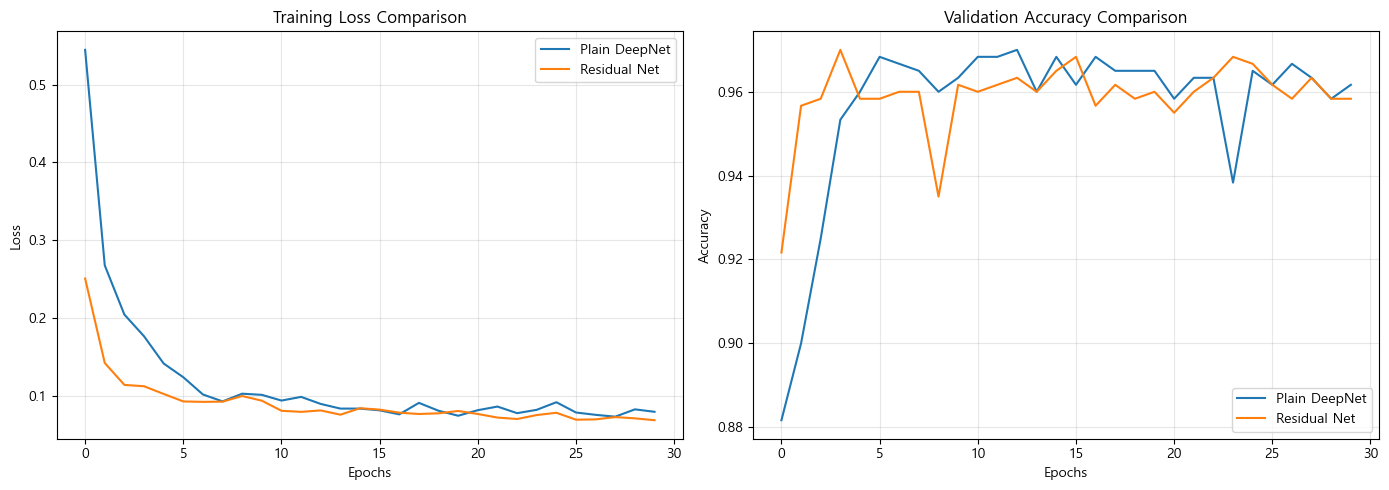

In [5]:
plain_model = build_deep_plain(layers=20, units=64)
history_plain = plain_model.fit(X_train_res, y_train_res, validation_data=(X_test_res, y_test_res),
                                epochs=30, batch_size=32, verbose=0)

res_model = build_residual_network(blocks=10, units=64)
history_res = res_model.fit(X_train_res, y_train_res, validation_data=(X_test_res, y_test_res),
                            epochs=30, batch_size=32, verbose=0)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_plain.history["loss"], label="Plain DeepNet")
plt.plot(history_res.history["loss"], label="Residual Net")
plt.title("Training Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history_plain.history["val_accuracy"], label="Plain DeepNet")
plt.plot(history_res.history["val_accuracy"], label="Residual Net")
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
## Part 2. L1, L2 Regularization 실습

이번 파트에서는 **L1, L2 Regularization** 이 Overfitting 완화에 어떻게 도움이 되는지 체감해봅니다.

- 작은 데이터셋과 복잡한 모델로 Overfitting 유도
- Regularization 유무 비교 (No Regularization, L1, L2, L1+L2)
- Validation Loss/Accuracy 곡선으로 비교


In [6]:
# 1. 데이터 준비 (작은 데이터셋 -> Overfitting 유도)
X_reg, y_reg = make_moons(n_samples=100, noise=0.25, random_state=42)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)

scaler_reg = StandardScaler()
X_train_reg = scaler_reg.fit_transform(X_train_reg)
X_test_reg = scaler_reg.transform(X_test_reg)


### 2-1. 모델 생성 함수 (Regularization 적용 가능)


In [7]:
def build_model(regularizer=None):
    # [TODO] Dense 레이어에 kernel_regularizer=regularizer 옵션을 적용하세요.
    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(shape=(2,)),
        tf.keras.layers.Dense(128, activation="relu", kernel_regularizer=regularizer),
        tf.keras.layers.Dense(128, activation="relu", kernel_regularizer=regularizer),
        tf.keras.layers.Dense(1, activation="sigmoid", kernel_regularizer=regularizer)
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model


### 2-2. Regularization 설정 및 모델 학습


In [8]:
models = {
    "No Regularization": build_model(),
    "L1 (0.001)": build_model(tf.keras.regularizers.l1(0.001)),
    "L2 (0.001)": build_model(tf.keras.regularizers.l2(0.001)),
    "L1+L2 (0.001)": build_model(tf.keras.regularizers.l1_l2(l1=0.001, l2=0.001))
}

histories = {}

for name, model in models.items():
    print(f"Training: {name}")
    history = model.fit(
        X_train_reg, y_train_reg,
        validation_data=(X_test_reg, y_test_reg),
        epochs=200,
        batch_size=16,
        verbose=0
    )
    histories[name] = history


Training: No Regularization
Training: L1 (0.001)
Training: L2 (0.001)
Training: L1+L2 (0.001)


### 2-3. 결과 시각화 (Loss & Accuracy)


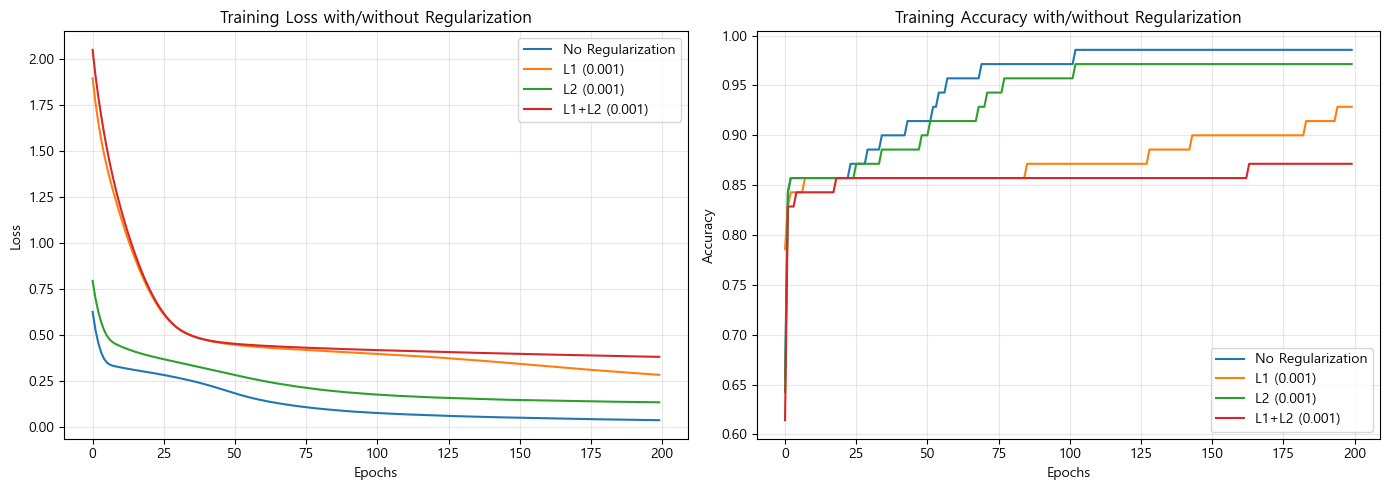

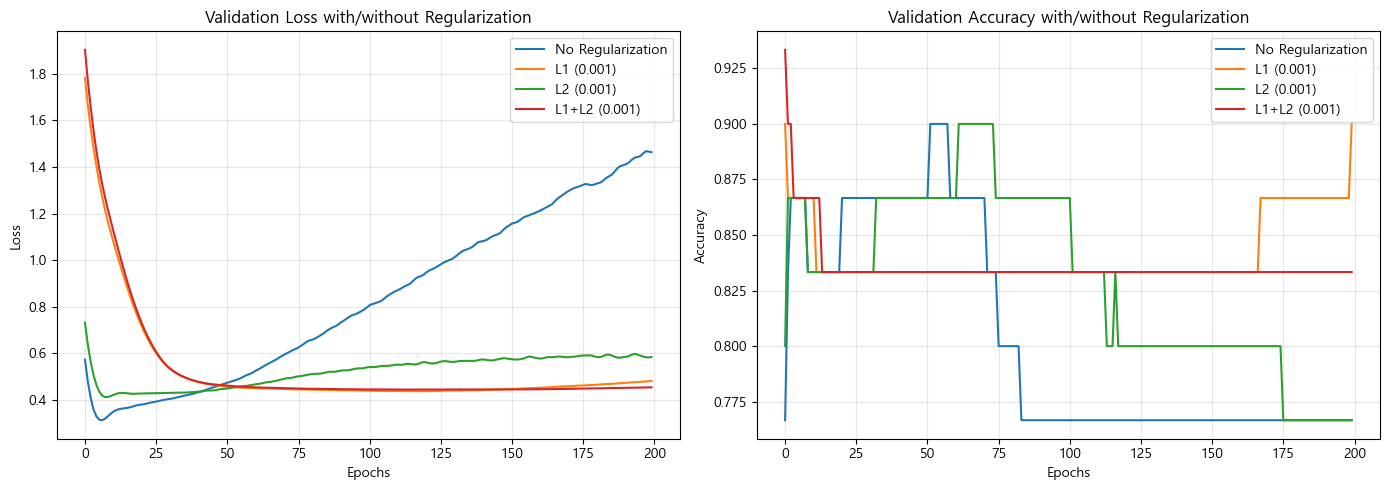

In [9]:
# 1. Training Loss & Accuracy
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
for name, history in histories.items():
    plt.plot(history.history["loss"], label=f"{name}")
plt.title("Training Loss with/without Regularization")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
for name, history in histories.items():
    plt.plot(history.history["accuracy"], label=f"{name}")
plt.title("Training Accuracy with/without Regularization")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Validation Loss & Accuracy
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
for name, history in histories.items():
    plt.plot(history.history["val_loss"], label=f"{name}")
plt.title("Validation Loss with/without Regularization")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
for name, history in histories.items():
    plt.plot(history.history["val_accuracy"], label=f"{name}")
plt.title("Validation Accuracy with/without Regularization")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## Part 3. Dropout 실습

이번 파트에서는 **Dropout** 이 Overfitting 완화에 어떻게 도움이 되는지 체감해봅니다.

- 작은 데이터셋과 복잡한 모델로 Overfitting 유도
- Dropout 유무 비교
- Validation Loss/Accuracy 곡선으로 비교


In [10]:
# 1. 데이터 준비 (작은 데이터셋 -> Overfitting 유도)
# (Part 2와 동일한 100개 make_moons 데이터 사용)
print(f"X_train shape: {X_train_reg.shape}, X_test shape: {X_test_reg.shape}")


X_train shape: (70, 2), X_test shape: (30, 2)


### 3-1. Dropout 없는 모델과 Dropout 적용 모델 정의


In [11]:
def build_model_with_dropout():
    # [TODO] Dense 레이어 사이에 tf.keras.layers.Dropout(0.5)를 추가하세요.
    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(shape=(2,)),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

def build_model_without_dropout():
    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(shape=(2,)),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model


### 3-2. 모델 학습 (Dropout 유무 비교) 및 결과 시각화


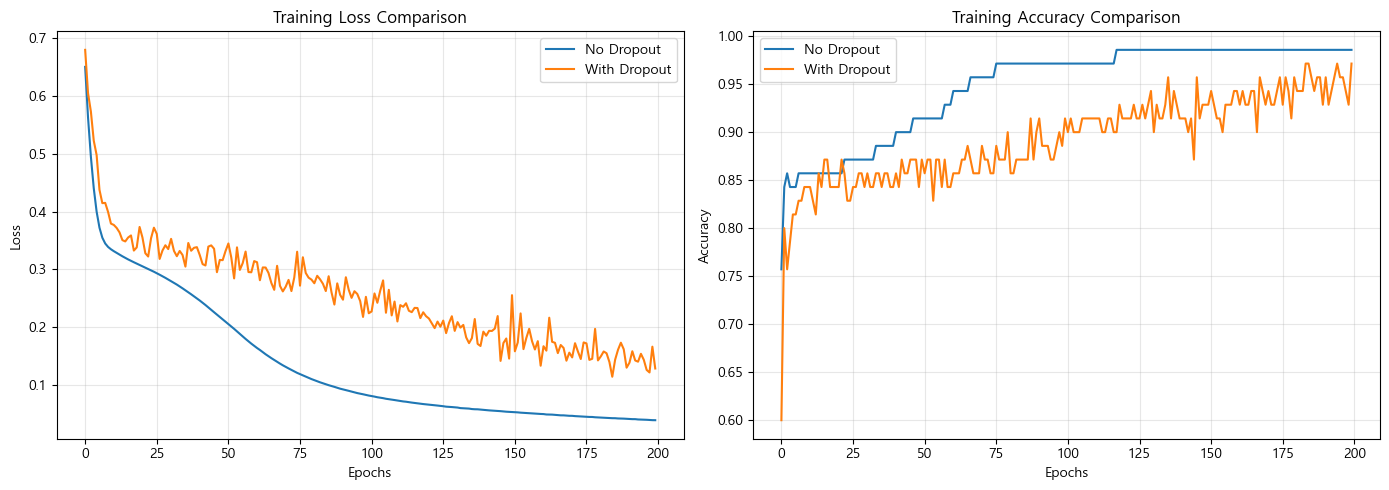

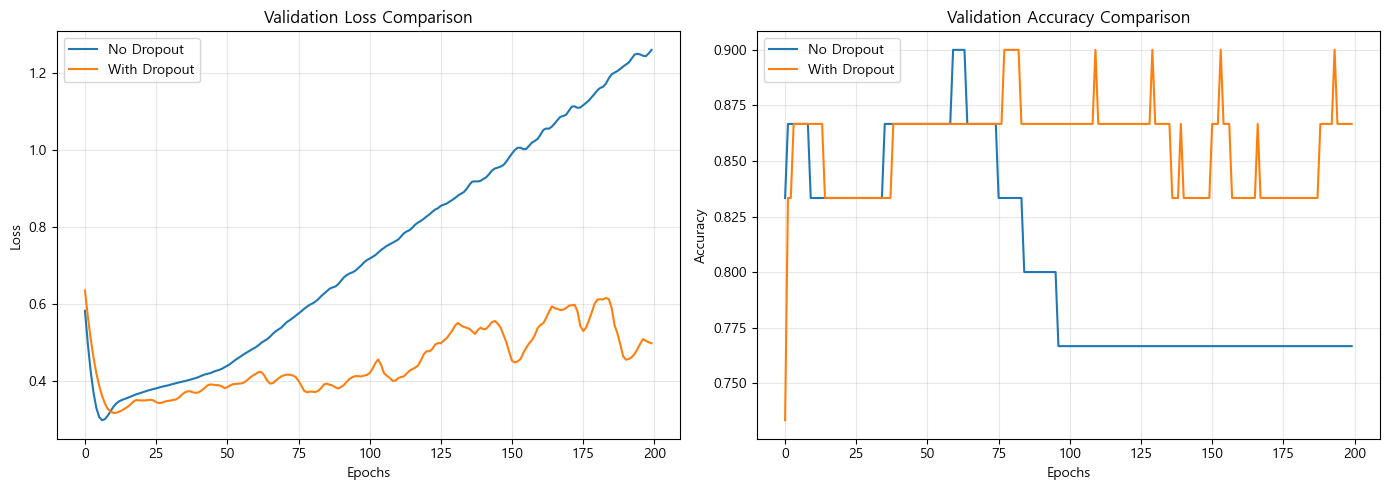

In [12]:
model_no_dropout = build_model_without_dropout()
model_with_dropout = build_model_with_dropout()

history_no_dropout = model_no_dropout.fit(
    X_train_reg, y_train_reg,
    validation_data=(X_test_reg, y_test_reg),
    epochs=200, batch_size=16, verbose=0
)

history_with_dropout = model_with_dropout.fit(
    X_train_reg, y_train_reg,
    validation_data=(X_test_reg, y_test_reg),
    epochs=200, batch_size=16, verbose=0
)

# 1. Training Loss & Accuracy 비교
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_no_dropout.history["loss"], label="No Dropout")
plt.plot(history_with_dropout.history["loss"], label="With Dropout")
plt.title("Training Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history_no_dropout.history["accuracy"], label="No Dropout")
plt.plot(history_with_dropout.history["accuracy"], label="With Dropout")
plt.title("Training Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Validation Loss & Accuracy 비교
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_no_dropout.history["val_loss"], label="No Dropout")
plt.plot(history_with_dropout.history["val_loss"], label="With Dropout")
plt.title("Validation Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history_no_dropout.history["val_accuracy"], label="No Dropout")
plt.plot(history_with_dropout.history["val_accuracy"], label="With Dropout")
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## Part 4. Balanced Data Augmentation & Class Weighting 실습

이번 실습에서는 **Class Imbalance 문제**를 다루는 두 가지 방법을 비교합니다.

- Baseline (불균형 데이터 그대로 학습)
- Balanced Data Augmentation (소수 클래스만 증강)
- Class Weighting (소수 클래스에 가중치 부여)

CIFAR-10 (Cat vs Dog) 데이터셋으로 실험합니다.


### 4-1. 데이터 준비 (CIFAR-10: Cat vs Dog, 불균형 만들기)


In [13]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()
y_train, y_test = y_train.flatten(), y_test.flatten()

# 클래스 3=Cat, 5=Dog
mask_train = (y_train == 3) | (y_train == 5)  # 3=Cat, 5=Dog
mask_test = (y_test == 3) | (y_test == 5)
X_train, y_train = X_train[mask_train], y_train[mask_train]
X_test, y_test = X_test[mask_test], y_test[mask_test]

# 라벨 재정의: Cat=0, Dog=1
y_train = (y_train == 5).astype(int)
y_test = (y_test == 5).astype(int)

# Cat 샘플 줄여서 불균형 만들기
# cat data를 20%만 사용
cat_idx = np.where(y_train == 0)[0]
dog_idx = np.where(y_train == 1)[0]
np.random.seed(42)
cat_idx_reduced = np.random.choice(cat_idx, size=len(cat_idx)//5, replace=False)
imbalanced_idx = np.concatenate([cat_idx_reduced, dog_idx])
X_train, y_train = X_train[imbalanced_idx], y_train[imbalanced_idx]

X_train = X_train.astype("float32")/255.0
X_test = X_test.astype("float32")/255.0

print("Train class distribution (imbalanced):", np.bincount(y_train))


Train class distribution (imbalanced): [1000 5000]


### 4-2. CNN 모델 정의


In [14]:
def build_model():
    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(shape=(32,32,3)),
        tf.keras.layers.Conv2D(32, (3,3), activation="relu"),
        tf.keras.layers.MaxPooling2D((2,2)),
        tf.keras.layers.Conv2D(64, (3,3), activation="relu"),
        tf.keras.layers.MaxPooling2D((2,2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model


### 4-3. Balanced Data Augmentation (소수 클래스만 증강)


In [15]:
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(X_train)

cat_imgs = X_train[y_train==0]
dog_imgs = X_train[y_train==1]
cat_labels = y_train[y_train==0]
dog_labels = y_train[y_train==1]

# [TODO] 다수 클래스(Dog) 수와 소수 클래스(Cat) 수의 차이를 계산하세요.
needed = len(dog_labels) - len(cat_labels)
print("부족한 소수 클래스(Cat) 샘플 수:", needed)
augmented_cats, augmented_labels = [], []

# 소수 클래스(Cat)만 증강
for X_batch, y_batch in datagen.flow(cat_imgs, cat_labels, batch_size=32, seed=42):
    augmented_cats.append(X_batch)
    augmented_labels.append(y_batch)
    if len(np.concatenate(augmented_labels)) >= needed:
        break

augmented_cats = np.concatenate(augmented_cats)[:needed]
augmented_labels = np.concatenate(augmented_labels)[:needed]

# [TODO] 원본 X_train과 증강된 augmented_cats를 np.concatenate로 합치세요.
X_balanced = np.concatenate([X_train, augmented_cats])
y_balanced = np.concatenate([y_train, augmented_labels])

print("Balanced train class distribution:", np.bincount(y_balanced))


부족한 소수 클래스(Cat) 샘플 수: 4000
Balanced train class distribution: [5000 5000]


### 4-4. Class Weighting 설정


In [16]:
# [TODO] compute_class_weight("balanced", ...)를 사용하여 클래스 가중치를 계산하세요.
class_weights = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)


Class Weights: {0: np.float64(3.0), 1: np.float64(0.6)}


### 4-5. 학습 (Baseline vs Balanced Augmentation vs Class Weighting)


In [17]:
histories_cifar = {}

# 1. Baseline
print("1. Baseline 학습 중...")
model_base = build_model()
histories_cifar["Baseline"] = model_base.fit(
    X_train, y_train, validation_data=(X_test, y_test),
    epochs=5, batch_size=64, verbose=0
)

# 2. Balanced Data Augmentation
print("2. Balanced Data Augmentation 학습 중...")
model_aug = build_model()
histories_cifar["Balanced Augmentation"] = model_aug.fit(
    X_balanced, y_balanced, validation_data=(X_test, y_test),
    epochs=5, batch_size=64, verbose=0
)

# 3. Class Weighting
print("3. Class Weighting 학습 중...")
model_weighted = build_model()
histories_cifar["Class Weighting"] = model_weighted.fit(
    X_train, y_train, validation_data=(X_test, y_test),
    epochs=5, batch_size=64, class_weight=class_weights, verbose=0
)


1. Baseline 학습 중...
2. Balanced Data Augmentation 학습 중...
3. Class Weighting 학습 중...


### 4-6. 결과 비교 시각화 (Validation Accuracy)


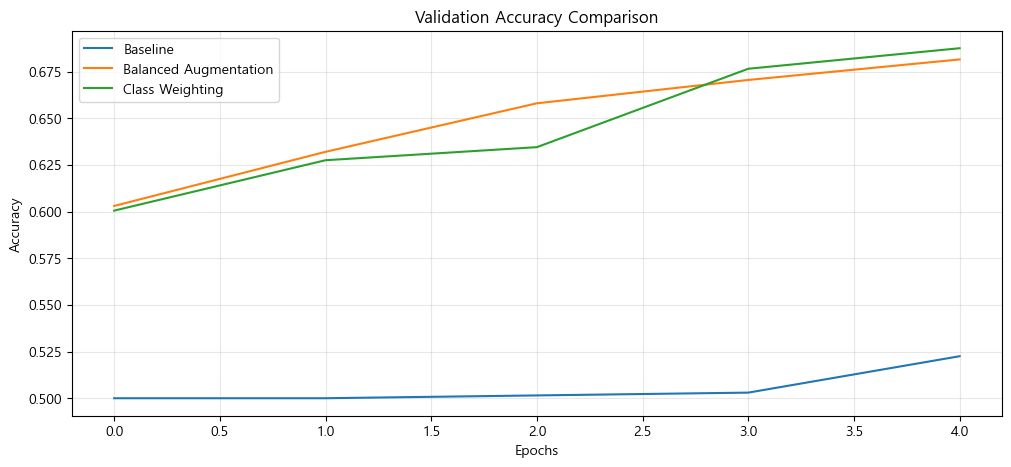

In [18]:
plt.figure(figsize=(12, 5))
for name, history in histories_cifar.items():
    plt.plot(history.history["val_accuracy"], label=name)
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### 4-7. 모델별 Confusion Matrix 및 Classification Report 비교


Classification Report (Baseline):
              precision    recall  f1-score   support

         Cat     0.8169    0.0580    0.1083      1000
         Dog     0.5117    0.9870    0.6740      1000

    accuracy                         0.5225      2000
   macro avg     0.6643    0.5225    0.3911      2000
weighted avg     0.6643    0.5225    0.3911      2000



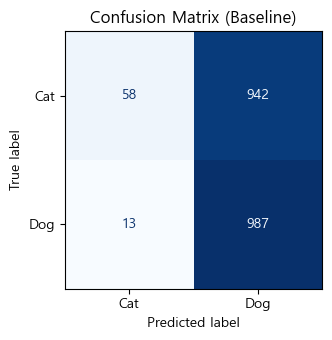

In [19]:
# 1. Baseline 평가
y_pred_base = (model_base.predict(X_test, verbose=0) > 0.5).astype(int).flatten()
print("Classification Report (Baseline):")
print(classification_report(y_test, y_pred_base, digits=4, target_names=["Cat", "Dog"]))

cm_base = confusion_matrix(y_test, y_pred_base)
fig, ax = plt.subplots(figsize=(4, 3.5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_base, display_labels=["Cat", "Dog"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix (Baseline)")
plt.tight_layout()
plt.show()


Classification Report (Augmentation):
              precision    recall  f1-score   support

         Cat     0.6925    0.6530    0.6722      1000
         Dog     0.6717    0.7100    0.6903      1000

    accuracy                         0.6815      2000
   macro avg     0.6821    0.6815    0.6812      2000
weighted avg     0.6821    0.6815    0.6812      2000



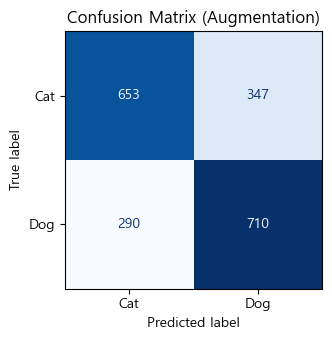

In [20]:
# 2. Balanced Data Augmentation 평가
y_pred_aug = (model_aug.predict(X_test, verbose=0) > 0.5).astype(int).flatten()
print("Classification Report (Augmentation):")
print(classification_report(y_test, y_pred_aug, digits=4, target_names=["Cat", "Dog"]))

cm_aug = confusion_matrix(y_test, y_pred_aug)
fig, ax = plt.subplots(figsize=(4, 3.5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_aug, display_labels=["Cat", "Dog"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix (Augmentation)")
plt.tight_layout()
plt.show()


Classification Report (Class weighting):
              precision    recall  f1-score   support

         Cat     0.6728    0.7300    0.7002      1000
         Dog     0.7049    0.6450    0.6736      1000

    accuracy                         0.6875      2000
   macro avg     0.6889    0.6875    0.6869      2000
weighted avg     0.6889    0.6875    0.6869      2000



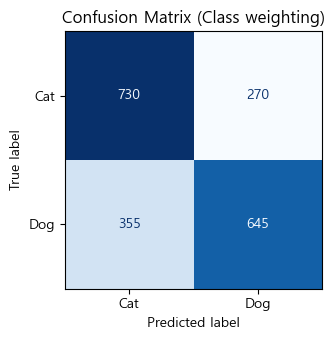

In [21]:
# 3. Class Weighting 평가
y_pred_weighted = (model_weighted.predict(X_test, verbose=0) > 0.5).astype(int).flatten()
print("Classification Report (Class weighting):")
print(classification_report(y_test, y_pred_weighted, digits=4, target_names=["Cat", "Dog"]))

cm_weighted = confusion_matrix(y_test, y_pred_weighted)
fig, ax = plt.subplots(figsize=(4, 3.5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_weighted, display_labels=["Cat", "Dog"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix (Class weighting)")
plt.tight_layout()
plt.show()


### 💡 [생각해보기 - 도전과제 종합 정리]
1. ResNet의 Skip Connection은 왜 일반 깊은 망보다 학습 손실을 빠르게 줄이고 깊은 층에서도 안정적으로 수렴하게 할까요?
2. L1, L2 가중치 규제와 Dropout은 각각 가중치를 어떻게 제어하여 과적합을 방지하나요?
3. 불균형 데이터셋에서 Baseline 대비 Class Weighting과 Balanced Data Augmentation을 적용했을 때 소수 클래스(Cat)의 재현율(Recall)과 F1-Score가 어떻게 개선되었나요?


#### 📝 [생각해보기 답변 - 도전과제 종합 정리]
1. **ResNet의 Skip Connection이 깊은 망에서도 안정적으로 학습되는 이유**:
   - 일반 깊은 신경망은 층이 깊어질수록 역전파되는 기울기가 점점 작아져서 앞쪽 층의 학습이 잘 안 되는데, ResNet은 입력을 그대로 다음 층에 더해주는 '지름길(Skip Connection)'이 있습니다. 이 덕분에 미분할 때 최소 1의 기울기가 그대로 보존되어 앞쪽 층까지 신호가 손실 없이 전달되므로, 층이 깊어져도 손실이 빠르게 줄어들고 안정적으로 수렴합니다.
2. **L1, L2 규제와 Dropout의 과적합 방지 원리**:
   - **L1 규제 (Lasso)**: 중요도가 떨어지는 가중치를 아예 0으로 만들어 버려서, 불필요한 특성을 자동으로 제거해주는 효과가 있습니다.
   - **L2 규제 (Ridge)**: 특정 가중치만 너무 커지지 않도록 전체 가중치를 골고루 작게 줄여주어(Weight Decay), 모델이 특정 입력에 과하게 민감해지는 것을 막아줍니다.
   - **Dropout**: 학습할 때 뉴런을 무작위로 껐다 켰다 하면서 특정 뉴런들끼리만 뭉쳐서 학습되는 것을 막고, 여러 네트워크를 앙상블하는 효과를 주어 과적합을 줄여줍니다.
3. **CIFAR-10 불균형 데이터셋(Cat 1,000장 vs Dog 5,000장)에서의 개선 결과**:
   - 50:50 균형 테스트셋(고양이 1,000장 vs 개 1,000장)으로 평가한 실제 실험 결과는 다음과 같았습니다:
     - **Baseline (그냥 학습)**: 소수 클래스인 고양이의 재현율(Recall)이 약 **5.8%**(F1-Score: 0.108)에 불과해, 거의 모든 고양이를 개로 오판했습니다.
     - **Balanced Data Augmentation (소수 클래스 증강)**: 고양이 재현율이 **65.3%**(F1-Score: 0.672)로 크게 올라갔습니다.
     - **Class Weighting (가중치 부여)**: 고양이 재현율이 **73.0%**(F1-Score: 0.700)까지 올라가 가장 좋은 성능을 보였습니다.
   - 즉, 소수 클래스에 가중치를 주거나 데이터를 늘려주는 기법을 적용하니 모델이 소수 클래스도 확실하게 인식할 수 있게 개선되었습니다.